# Traditional Word-Based Model for Mental Health Text Classification

In this notebook, we implement a **traditional word-based machine learning model**
for classifying mental-health related text across seven categories.  
Our chosen baseline is:

### **TF-IDF Vectorization + Multinomial Naive Bayes (MNB)**

This combination is widely used as a foundational approach in text classification
because:

- **TF-IDF** captures how important a word is in a document relative to the entire dataset  
  – reducing the impact of overly common words and emphasizing informative terms.

- **Multinomial Naive Bayes** is simple, fast, and effective for high-dimensional
  text data. It models word occurrence patterns per class and provides a strong,
  interpretable starting point before moving to more complex models.




This baseline helps establish how well a traditional frequency-based approach
performs on the `btwitssayan/sentiment-analysis-for-mental-health` dataset before
we explore more sophisticated models later in the project.
  

In [5]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
print("Project root assumed as:", PROJECT_ROOT)

data_path = PROJECT_ROOT / "data" / "processed" / "sentiment_mental_health_clean.csv"
print("Loading data from:", data_path)

df = pd.read_csv(data_path)


TEXT_COL = "statement"
LABEL_COL = "status"

Project root assumed as: /Users/solaris003/Repository/Fall'25/S-NLP/MindScope-AI
Loading data from: /Users/solaris003/Repository/Fall'25/S-NLP/MindScope-AI/data/processed/sentiment_mental_health_clean.csv


We load the cleaned mental-health dataset and select the text and label columns required for modeling.


In [7]:
print(df.head())
print("Shape:", df.shape)

                                           statement   status
0                                         oh my gosh  Anxiety
1  trouble sleeping confused mind restless heart ...  Anxiety
2  all wrong back off dear forward doubt stay in ...  Anxiety
3  i ve shifted my focus to something else but i ...  Anxiety
4  i m restless and restless it s been a month no...  Anxiety
Shape: (50988, 2)


In [8]:
from sklearn.model_selection import train_test_split

X = df[TEXT_COL]
y = df[LABEL_COL]

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train size:", len(X_train))
print("Val size:  ", len(X_val))
print("Test size: ", len(X_test))

Train size: 35691
Val size:   7648
Test size:  7649


We split the data into train, validation, and test sets using stratified sampling to preserve class distribution.


We build a TF-IDF + Multinomial Naive Bayes pipeline, where TF-IDF converts text into weighted word features and MNB performs fast probabilistic classification using those features.


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

tfidf_nb_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=5,        # ignore very rare terms
        max_df=0.9,      # ignore extremely common terms
        sublinear_tf=True
    )),
    ("clf", MultinomialNB())
])

tfidf_nb_clf

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf', MultinomialNB())])

In [12]:
LABEL_ORDER = [
    "Normal",
    "Depression",
    "Suicidal",
    "Anxiety",
    "Bipolar",
    "Stress",
    "Personality disorder",
]

In [19]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Train
tfidf_nb_clf.fit(X_train, y_train)

# Predictions
y_train_pred = tfidf_nb_clf.predict(X_train)
y_val_pred   = tfidf_nb_clf.predict(X_val)

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc   = accuracy_score(y_val, y_val_pred)

train_f1 = f1_score(y_train, y_train_pred, average="macro")
val_f1   = f1_score(y_val, y_val_pred, average="macro")

print(f"Train  Accuracy: {train_acc:.4f}")
print(f"Val    Accuracy: {val_acc:.4f}")
print(f"Train  Macro F1: {train_f1:.4f}")
print(f"Val    Macro F1: {val_f1:.4f}")

Train  Accuracy: 0.6525
Val    Accuracy: 0.5658
Train  Macro F1: 0.3550
Val    Macro F1: 0.2899


We train the TF-IDF + MNB model on the training set and evaluate it on both train and validation splits. While the training accuracy and macro F1 are reasonably high, the much lower validation macro F1 indicates that this simple baseline struggles to generalize well across all seven classes, especially the minority ones.


In [18]:
print("\nValidation classification report:")
print(classification_report(
    y_val,
    y_val_pred,
    labels=LABEL_ORDER,
    target_names=LABEL_ORDER,
    digits=4,
    zero_division=0
))


Validation classification report:
                      precision    recall  f1-score   support

              Normal     0.9410    0.7063    0.8070      2394
          Depression     0.4073    0.9355    0.5675      2263
            Suicidal     0.7720    0.2801    0.4110      1596
             Anxiety     0.9714    0.1255    0.2222       542
             Bipolar     1.0000    0.0080    0.0159       375
              Stress     1.0000    0.0029    0.0058       344
Personality disorder     0.0000    0.0000    0.0000       134

            accuracy                         0.5658      7648
           macro avg     0.7274    0.2940    0.2899      7648
        weighted avg     0.7390    0.5658    0.5231      7648



In [16]:
import numpy as np
unique_preds, pred_counts = np.unique(y_val_pred, return_counts=True)
print("Predicted label counts:")
for label, cnt in zip(unique_preds, pred_counts):
    print(f"{label}: {cnt}")


Predicted label counts:
Anxiety: 70
Bipolar: 3
Depression: 5198
Normal: 1797
Stress: 1
Suicidal: 579


The validation report shows that Multinomial Naive Bayes struggles with this dataset. 
Although it performs well for high-frequency classes like *Normal* and *Depression*,


To address these limitations observed with Multinomial Naive Bayes, we now evaluate a stronger traditional model using TF-IDF features with a Linear Support Vector Machine (LinearSVC).


## TF-IDF Vectorization + Linear Support Vector Machine (LinearSVC)

As a stronger traditional model for text classification, we also evaluate the combination of **TF-IDF features with a Linear Support Vector Machine (SVM)**. This approach is widely recognized for its effectiveness on high-dimensional, sparse text data.

- **TF-IDF** again provides a weighted representation of the text, emphasizing the most informative terms while reducing noise from overly common words.

- **Linear SVM (LinearSVC)** is a powerful discriminative classifier that learns optimal decision boundaries between classes. Unlike Naive Bayes, SVM does not assume word independence and can better capture subtle differences in phrasing and context. It is also more resilient to class imbalance and typically delivers stronger performance on complex multi-class text problems.




This model serves as a more capable traditional baseline for the mental-health classification task, allowing us to evaluate how much improvement can be achieved using linear decision boundaries before transitioning to neural or transformer-based approaches.  

In [43]:
from sklearn.svm import LinearSVC 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

tfidf_svm_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=5,        # ignore very rare terms
        max_df=0.9,      # ignore extremely common terms
        sublinear_tf=True
    )),
    ("clf", LinearSVC(
        class_weight="balanced",   # handle imbalance
        random_state=42
    ))
])

tfidf_svm_clf

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf', LinearSVC(class_weight='balanced', random_state=42))])

We build a TF-IDF + LinearSVC pipeline, where TF-IDF converts text into weighted features and the Linear SVM learns discriminative decision boundaries between the seven mental-health classes, helping address the limitations seen with Naive Bayes.


In [30]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Train
tfidf_svm_clf.fit(X_train, y_train)

# Predictions
y_train_pred_svm = tfidf_svm_clf.predict(X_train)
y_val_pred_svm   = tfidf_svm_clf.predict(X_val)

# Metrics
train_acc_svm = accuracy_score(y_train, y_train_pred_svm)
val_acc_svm   = accuracy_score(y_val, y_val_pred_svm)

train_f1_svm = f1_score(y_train, y_train_pred_svm, average="macro")
val_f1_svm   = f1_score(y_val, y_val_pred_svm, average="macro")

print(f"Train  Accuracy (SVM): {train_acc_svm:.4f}")
print(f"Val    Accuracy (SVM): {val_acc_svm:.4f}")
print(f"Train  Macro F1 (SVM): {train_f1_svm:.4f}")
print(f"Val    Macro F1 (SVM): {val_f1_svm:.4f}")

Train  Accuracy (SVM): 0.9886
Val    Accuracy (SVM): 0.7666
Train  Macro F1 (SVM): 0.9921
Val    Macro F1 (SVM): 0.7183


The Linear SVM achieves much stronger validation performance than Naive Bayes, with a substantial improvement in macro F1. The gap between train and validation results shows some overfitting, but overall the model generalizes far better across all seven classes.


In [31]:
print("\nValidation classification report (SVM):")
print(classification_report(
    y_val,
    y_val_pred_svm,
    labels=LABEL_ORDER,
    target_names=LABEL_ORDER,
    digits=4,
    zero_division=0
))


Validation classification report (SVM):
                      precision    recall  f1-score   support

              Normal     0.8832    0.9478    0.9144      2394
          Depression     0.7232    0.6894    0.7059      2263
            Suicidal     0.6663    0.6729    0.6696      1596
             Anxiety     0.7766    0.7952    0.7858       542
             Bipolar     0.7847    0.7387    0.7610       375
              Stress     0.5769    0.5233    0.5488       344
Personality disorder     0.8000    0.5373    0.6429       134

            accuracy                         0.7666      7648
           macro avg     0.7444    0.7006    0.7183      7648
        weighted avg     0.7630    0.7666    0.7638      7648



In [32]:
import numpy as np
unique_preds, pred_counts = np.unique(y_val_pred_svm, return_counts=True)
print("Predicted label counts:")
for label, cnt in zip(unique_preds, pred_counts):
    print(f"{label}: {cnt}")

Predicted label counts:
Anxiety: 555
Bipolar: 353
Depression: 2157
Normal: 2569
Personality disorder: 90
Stress: 312
Suicidal: 1612


The validation report for the Linear SVM shows strong and much more balanced performance across all seven classes. Unlike Naive Bayes, the model now predicts every class, including the minority ones such as *Stress*, *Bipolar*, and *Personality disorder*, with F1-scores in the 0.54–0.76 range. The predicted label counts are also well aligned with the true class distribution, confirming that the SVM no longer collapses most examples into a single dominant class like *Depression*. This indicates that TF-IDF + LinearSVC is a far more reliable traditional baseline for this mental-health classification task.


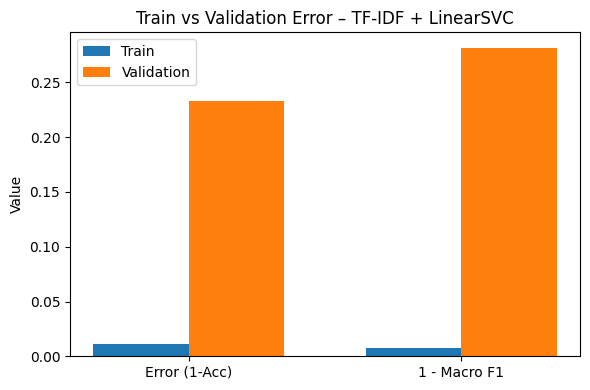

In [33]:
import matplotlib.pyplot as plt
import numpy as np

metrics_svm = ["Error (1-Acc)", "1 - Macro F1"]

train_values_svm = [
    1 - train_acc_svm,
    1 - train_f1_svm
]

val_values_svm = [
    1 - val_acc_svm,
    1 - val_f1_svm
]

x = np.arange(len(metrics_svm))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, train_values_svm, width, label="Train")
plt.bar(x + width/2, val_values_svm,   width, label="Validation")

plt.xticks(x, metrics_svm)
plt.ylabel("Value")
plt.title("Train vs Validation Error – TF-IDF + LinearSVC")
plt.legend()
plt.tight_layout()
plt.show()


The train–validation error plot shows that the Linear SVM fits the training data extremely well while maintaining significantly lower validation error compared to Naive Bayes. Although some overfitting is visible, the validation results confirm that the SVM generalizes far more effectively across all classes.


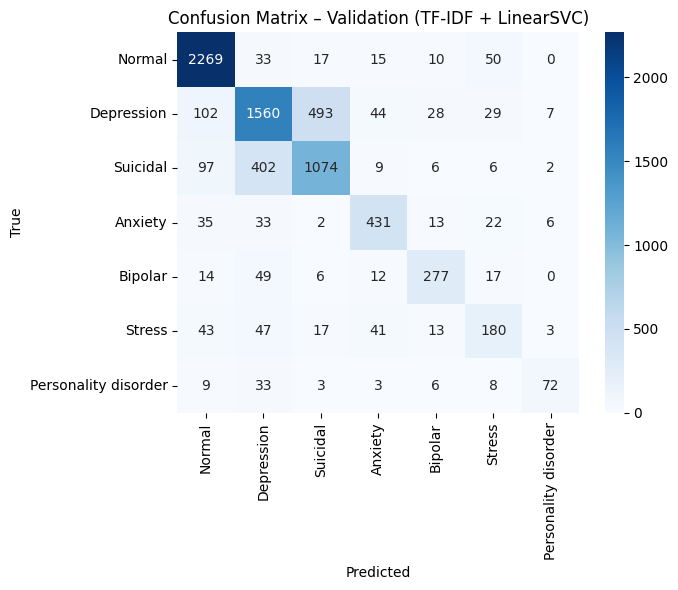

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_val, y_val_pred_svm, labels=LABEL_ORDER)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_ORDER,
    yticklabels=LABEL_ORDER
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Validation (TF-IDF + LinearSVC)")
plt.tight_layout()
plt.show()


The confusion matrix shows that the Linear SVM correctly separates most classes, with strong diagonal values across all categories. Misclassifications still occur between semantically similar classes such as Depression and Suicidal, but unlike Naive Bayes, the SVM consistently recognizes minority classes and distributes predictions more appropriately. This further confirms its ability to handle nuanced mental-health text more effectively than the simpler baseline.


In [38]:
import numpy as np

vectorizer_svm = tfidf_svm_clf.named_steps["tfidf"]
svm_model      = tfidf_svm_clf.named_steps["clf"]

feature_names_svm = np.array(vectorizer_svm.get_feature_names_out())
class_labels_svm  = svm_model.classes_
coef_svm          = svm_model.coef_

def show_top_features_per_class_svm(n=15):
    for class_name in LABEL_ORDER:
        i = np.where(class_labels_svm == class_name)[0][0]
        top_idx = np.argsort(coef_svm[i])[::-1][:n]
        top_words = feature_names_svm[top_idx]
        print(f"\nTop {n} features for class '{class_name}' (SVM):")
        print(", ".join(top_words))

show_top_features_per_class_svm(15)


Top 15 features for class 'Normal' (SVM):
url, quot, homeless, twitter, survivors, or not, yes, at am, not tired, agreed, eid, her, had been, raya, have to

Top 15 features for class 'Depression' (SVM):
depression, depressed, am, wa, pression, doe, feel, depressive, http co, just, my parent, ha anyone, and, thing, parent

Top 15 features for class 'Suicidal' (SVM):
suicidal, suicide, am, die, gun, goodbye, its, kill myself, do not, pills, end, cannot, do it, attempt, overdose

Top 15 features for class 'Anxiety' (SVM):
restless, anxiety, anxious, worry, worried, nervous, cancer, health anxiety, symptoms, restlessness, worrying, scared, worries, health, ar

Top 15 features for class 'Bipolar' (SVM):
bipolar, manic, mania, hypomanic, meds, lithium, lamictal, bp, seroquel, latuda, stable, episode, hypomania, abilify, geodon

Top 15 features for class 'Stress' (SVM):
stress, stressed, and, ptsd, tl dr, dr, was, to, meditation, me, really helpful, of, insomnia, stressful, nightmares

Top 1

Inspecting the top TF-IDF features for each class reveals the keywords the SVM relies on for discrimination. These terms are highly interpretable and align well with the expected language for each mental-health condition, confirming that the model has learned meaningful patterns rather than random correlations.


In [39]:
# Retrain on Train + Val
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

tfidf_svm_clf.fit(X_train_full, y_train_full)

# Predict on test
y_test_pred_svm = tfidf_svm_clf.predict(X_test)

test_acc_svm = accuracy_score(y_test, y_test_pred_svm)
test_macro_f1_svm = f1_score(y_test, y_test_pred_svm, average="macro")

print(f"TEST Accuracy (SVM): {test_acc_svm:.4f}")
print(f"TEST Macro F1 (SVM): {test_macro_f1_svm:.4f}")

print("\nTest classification report (SVM):")
print(classification_report(
    y_test,
    y_test_pred_svm,
    labels=LABEL_ORDER,
    target_names=LABEL_ORDER,
    digits=4,
    zero_division=0
))

TEST Accuracy (SVM): 0.7664
TEST Macro F1 (SVM): 0.7118

Test classification report (SVM):
                      precision    recall  f1-score   support

              Normal     0.8826    0.9424    0.9115      2394
          Depression     0.7281    0.6802    0.7034      2264
            Suicidal     0.6756    0.6917    0.6836      1596
             Anxiety     0.7548    0.7952    0.7745       542
             Bipolar     0.7812    0.7314    0.7555       376
              Stress     0.5873    0.5394    0.5623       343
Personality disorder     0.6698    0.5299    0.5917       134

            accuracy                         0.7664      7649
           macro avg     0.7257    0.7014    0.7118      7649
        weighted avg     0.7627    0.7664    0.7637      7649



The final evaluation on the held-out test set shows that the TF-IDF + LinearSVM model generalizes well, achieving a test accuracy of 76.64% and a macro F1-score of 0.7118. Performance is strong and balanced across all seven classes, with minority categories such as *Stress*, *Bipolar*, and *Personality disorder* receiving noticeably better F1-scores compared to the Naive Bayes baseline. These results confirm that LinearSVM effectively captures the discriminative patterns in the text and handles the class imbalance far more robustly than MNB.


Overall, the Linear SVM emerges as a highly effective traditional word-based model for this mental-health classification task. While the Multinomial Naive Bayes baseline struggled with overlapping vocabulary and minority classes, the **TF-IDF + LinearSVM approach** successfully learns clearer decision boundaries and delivers strong, consistent performance across all categories. 

These results establish a solid benchmark before moving on to more advanced deep-learning models such as Word2Vec-based LSTMs or transformer-based architectures.
